# Qwen2-VL-7B image-text fine-tuning using the LaTeX OCR dataset

This discusses finetuning techniques, pros and cons and supervised finetuning Qwen model using `unsloth` library.

Original YouTube video: [Finetuning Qwen2 VL on LaTeX image with an IITian](https://youtu.be/i5kDh35sJ9M)

[Original Colab notebook](https://colab.research.google.com/drive/1qETrTam8E9iskfUMK-H9fVzD3foS7hkB),
[Additional Kaggle notebook](https://www.kaggle.com/code/danielhanchen/qwen2-vision-finetuning-unsloth-kaggle)

[LaTeX OCR dataset](https://huggingface.co/datasets/unsloth/LaTeX_OCR)

Article [Introduction to Transformers and Attention Mechanisms](https://medium.com/@kalra.rakshit/introduction-to-transformers-and-attention-mechanisms-c29d252ea2c5)

[Unsloth: A Guide from Basics to Fine-Tuning Vision Models](https://learnopencv.com/unsloth-guide-efficient-llm-fine-tuning/)

## Install `unsloth` library

In [1]:
# # Previous install does not work. Recursion error
# !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo
# !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
# !pip install --no-deps unsloth

# # Official URL does not work: https://unsloth.ai/docs/get-started/install/google-colab
# !pip install "unsloth[colab-new] @ git+https:/github.com/unslothai/unsloth.git"
# !pip install --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes

# Just do it simple!. For local use, use a separate virtual environment
!pip install unsloth

In [2]:
import unsloth

print(f"Unsloth version: {unsloth.__version__}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth version: 2026.2.1


## Import libraries. Helper functions

In [3]:
import unsloth # must be the very first import
import torch
import matplotlib.pyplot as plt

# unsloth libraries + helper libraries
from unsloth import FastVisionModel, is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

from datasets import load_dataset
from transformers import TextStreamer
from IPython.display import display, Image


INSTRUCTION = "Write the LaTeX representation for this image."


def show(image):
    """ Show image using matplotlib """
    fig = plt.figure(figsize=(5, 1.5))
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def latex_to_image(latex_str, save_path="formula.png"):
    """ Convert LaTeX text string to the image """
    # Remove special char '$' and substrings
    clean_text = (
        latex_str.replace("\n", "")
                 .replace("```latex", "")
                 .replace("```", "")
                 .replace("$", "")
                 .strip()
    )
    print(clean_text)  # show text

    fig = plt.figure(figsize=(4, 1))  # create a figure with a specific size

    # Add text using LaTeX formatting (r"$...$")
    plt.text(0.5, 0.5, rf"${clean_text}$", size=30, va="center", ha="center")
    plt.axis("off")  # hide axes

    try:
        # Save with tight bounding box to remove white space
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, transparent=False)
        plt.close()
    except Exception as e:
        print(f"Can not show image. Error: {type(e).__name__} — {e}")
        plt.close()
        return

    display(Image("formula.png"))  # show image


def generate(idx, dataset):
    """ Generate prediction """
    img = dataset[idx]["image"]
    txt = dataset[idx]["text"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": INSTRUCTION},
                {"type": "image"},
            ]
        }
    ]

    request = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize = False,
    )

    inputs = tokenizer(
        img,
        request,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")

    text_streamer = TextStreamer(tokenizer, skip_prompt=True)

    outputs = model.generate(
        **inputs,
        streamer=text_streamer,
        max_new_tokens=128,  # 128 tokens ≈ 512 chars
        use_cache=True,
        temperature=1.0,  # t=1.5 more random
        min_p=0.1,  # only > 10% tokens will be used for temperature

        # If you are using a newer version of Hugging Face transformers, the
        # static cache implementation might conflict with Unsloth's optimizations.
        # Explicitly disable it:
        cache_implementation=None,

        # Ensure the pad_token_id is set correctly for both the model and the tokenizer.
        # Unsloth models often default to a specific ID (e.g., 128001 or 128004),
        # but setting it explicitly in the generate call can resolve issues:
        pad_token_id=tokenizer.eos_token_id,
    )

    response_tokens = outputs[:, inputs.input_ids.shape[1]:]
    generated_txt = tokenizer.batch_decode(response_tokens, skip_special_tokens=True)[0]

    print(f"\n----------------\nGenerated:\t{generated_txt}")
    print(f"Actual:\t\t{txt}\n----------------\n")

    latex_to_image(generated_txt)
    show(img)


def convert_to_json(sample):
    """ JSON text for the LLM model """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": INSTRUCTION},
                {"type": "image", "image": sample["image"]}
            ]
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": sample["text"]}]
        }
    ]
    return {"messages": messages}

## Download LLM

**Important note**: 4-bit integer model has no gradients in weights for backpropagation.

So we fine-tune (train) low-rank (small) LoRA (Low-Rank Adaptation) matrices (adapters) instead ☺, but not the model itself.

In [4]:
# 4-bit integer model has no gradients in weights for backpropagation.
# So we fine-tune (train) low-rank (small) LoRA matrices (adapters) instead :-)

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-7B-Instruct",
    load_in_4bit=True,  # use 4-bit models to save memory
    use_gradient_checkpointing="unsloth",  # save VRAM on 30%
)

==((====))==  Unsloth 2026.2.1: Fast Qwen2_Vl patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [5]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,

    r=16,  # rank of LoRA matrices. Could be 8
    # Fine-tune small LoRA matrices, but not the model itself :-)
    # Best when r == lora_alpha
    lora_alpha=16,   # could be 32, but more memory
    lora_dropout=0,  # could be 0.05 or so
    bias="none",
    random_state = 3407,  # random seed
    use_rslora=False,  # don't use Rank-Stabilized LoRA (RSLoRA)
    loftq_config=None,  # disable LoRA loft config quantization technique
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


In [6]:
# Show LLM architecture
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (model): Qwen2VLModel(
        (visual): Qwen2VisionTransformerPretrainedModel(
          (patch_embed): PatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-18): 19 x Qwen2VLVisionBlock(
              (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (attn): VisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1280, out_features=3840, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1280, out_features=16, bias=Fals

## Download dataset

In [7]:
# Load the dataset
dataset = load_dataset("unsloth/Latex_OCR", split="train")

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
}) 

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40 at 0x7BC5F0DFF7A0>, 'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'} 



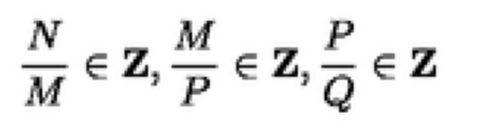

{ \frac { N } { M } } \in { \bf Z } , { \frac { M } { P } } \in { \bf Z } , { \frac { P } { Q } } \in { \bf Z }


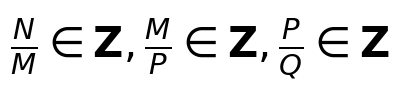

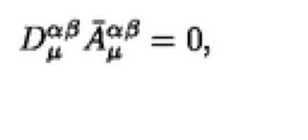

D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,


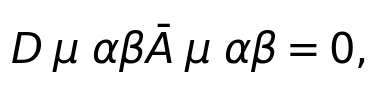

In [8]:
print(dataset, "\n")
print(dataset[0], "\n")

show(dataset[0]["image"])
txt = dataset[0]["text"]
latex_to_image(txt)
print("\n")

show(dataset[1]["image"])
txt = dataset[1]["text"]
latex_to_image(txt)

$$\mathbf { N } _ { M } \in \mathbf { Z } , \; \mathbf { M } _ { P } \in \mathbf { Z } , \; \mathbf { P } _ { Q } \in \mathbf { Z }$$<|im_end|>

----------------
Generated:	$$\mathbf { N } _ { M } \in \mathbf { Z } , \; \mathbf { M } _ { P } \in \mathbf { Z } , \; \mathbf { P } _ { Q } \in \mathbf { Z }$$
Actual:		{ \frac { N } { M } } \in { \bf Z } , { \frac { M } { P } } \in { \bf Z } , { \frac { P } { Q } } \in { \bf Z }
----------------

\mathbf { N } _ { M } \in \mathbf { Z } , \; \mathbf { M } _ { P } \in \mathbf { Z } , \; \mathbf { P } _ { Q } \in \mathbf { Z }


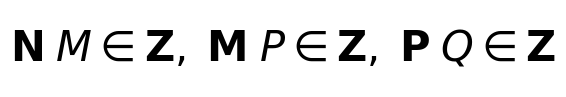

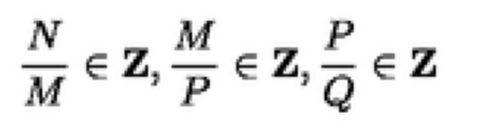

$$D _ { \mu } B \tilde { A } _ { \mu } ^ { B } = 0 ,$$<|im_end|>

----------------
Generated:	$$D _ { \mu } B \tilde { A } _ { \mu } ^ { B } = 0 ,$$
Actual:		D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,
----------------

D _ { \mu } B \tilde { A } _ { \mu } ^ { B } = 0 ,


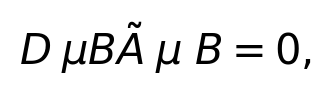

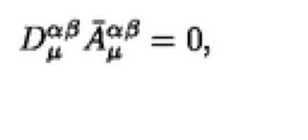

$$H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \xi ^ { \dagger } \partial _ { \lambda } \xi + V ( \lambda ) \xi ^ { \dagger } \xi \right\} \, .$$<|im_end|>

----------------
Generated:	$$H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \xi ^ { \dagger } \partial _ { \lambda } \xi + V ( \lambda ) \xi ^ { \dagger } \xi \right\} \, .$$
Actual:		H ^ { \prime } = \beta N \int d \lambda \biggl \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \biggr \} \ .
----------------

H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \xi ^ { \dagger } \partial _ { \lambda } \xi + V ( \lambda ) \xi ^ { \dagger } \xi \right\} \, .


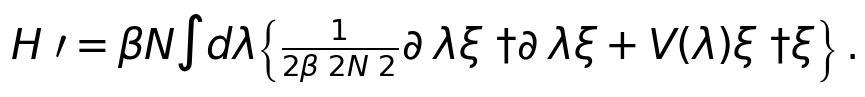

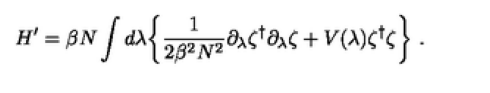

The LaTeX representation for the image is:

\[
\sigma^{\mu} \lambda^{\alpha} \frac{\lambda^{\alpha}}{2 \mu^{\mu}}
\]<|im_end|>

----------------
Generated:	The LaTeX representation for the image is:

\[
\sigma^{\mu} \lambda^{\alpha} \frac{\lambda^{\alpha}}{2 \mu^{\mu}}
\]
Actual:		\sigma ^ { \mu } \frac { \lambda ^ { a } } { 2 } A _ { \mu } ^ { a } .
----------------

The LaTeX representation for the image is:\[\sigma^{\mu} \lambda^{\alpha} \frac{\lambda^{\alpha}}{2 \mu^{\mu}}\]
Can not show image. Error: ValueError — 
The LaTeX representation for the image is:\[\sigma^{\mu} \lambda^{\alpha} \frac{\lambda^{\alpha}}{2 \mu^{\mu}}\]
                                          ^
ParseFatalException: Unknown symbol: \[, found '\'  (at char 42), (line:1, col:43)


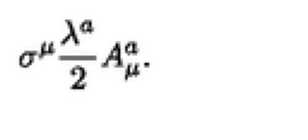

$$\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }$$<|im_end|>

----------------
Generated:	$$\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }$$
Actual:		\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }
----------------

\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }


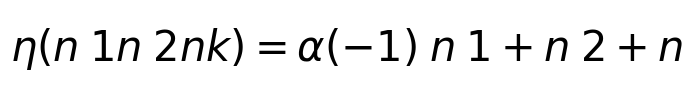

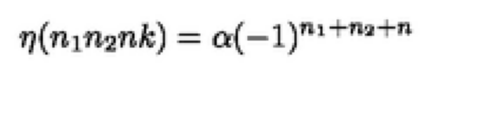

$${ \left( 4 \pi N \xi ^ { 2 } ( s ) \right) } ^ { - 1 } F _ { \mu } [ \xi | s ] = - D ^ { \nu } ( s ) L _ { \mu \nu } [ \xi | s ] ,$$<|im_end|>

----------------
Generated:	$${ \left( 4 \pi N \xi ^ { 2 } ( s ) \right) } ^ { - 1 } F _ { \mu } [ \xi | s ] = - D ^ { \nu } ( s ) L _ { \mu \nu } [ \xi | s ] ,$$
Actual:		( 4 \pi { \bar { N } } \dot { \xi } ^ { 2 } ( s ) ) ^ { - 1 } F _ { \mu } [ \xi | s ] = - { \cal D } ^ { \nu } ( s ) L _ { \mu \nu } [ \xi | s ] ,
----------------

{ \left( 4 \pi N \xi ^ { 2 } ( s ) \right) } ^ { - 1 } F _ { \mu } [ \xi | s ] = - D ^ { \nu } ( s ) L _ { \mu \nu } [ \xi | s ] ,


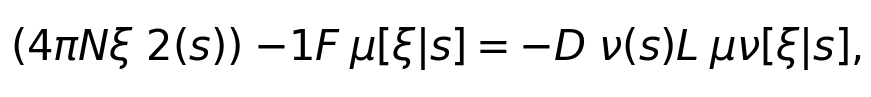

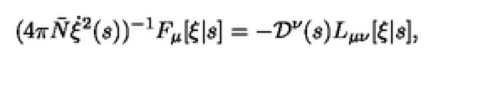

$$p _ { \mu } T ^ { \mu \nu } \rightarrow A V = 2 m _ { \nu } T ^ { \mu \nu } + p _ { \mu }$$<|im_end|>

----------------
Generated:	$$p _ { \mu } T ^ { \mu \nu } \rightarrow A V = 2 m _ { \nu } T ^ { \mu \nu } + p _ { \mu }$$
Actual:		p _ { \mu } T _ { \mu \nu } ^ { S \rightarrow A V } = 2 m i T _ { \nu } ^ { S \rightarrow P V }
----------------

p _ { \mu } T ^ { \mu \nu } \rightarrow A V = 2 m _ { \nu } T ^ { \mu \nu } + p _ { \mu }


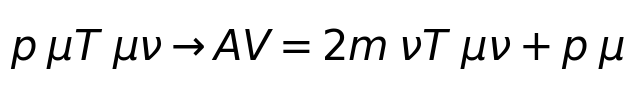

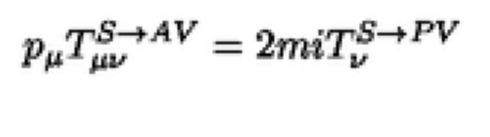

$$F [ r _ { - \varepsilon } ( \alpha ) ] =$$<|im_end|>

----------------
Generated:	$$F [ r _ { - \varepsilon } ( \alpha ) ] =$$
Actual:		F [ \tau _ { - \varepsilon } ( \alpha ) ] =
----------------

F [ r _ { - \varepsilon } ( \alpha ) ] =


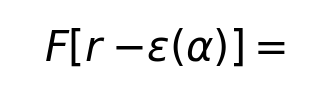

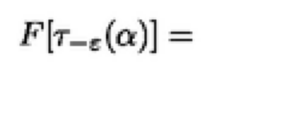

$$f _ { 0 } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \neq ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \operatorname* { d e t } g _ { I J } }$$<|im_end|>

----------------
Generated:	$$f _ { 0 } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \neq ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \operatorname* { d e t } g _ { I J } }$$
Actual:		f _ { 9 } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \ne ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \det g _ { I J } }
----------------

f _ { 0 } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \neq ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \operatorname* { d e t } g _ { I J } }
Can not show image. Error: ValueError — 
f _ { 0 } ^ { A } = V _ { 1 1 } \sum _ { (

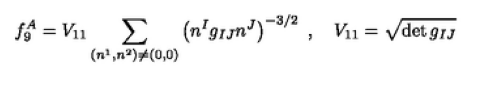

$$w _ { \mathrm { c o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } \right] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,$$<|im_end|>

----------------
Generated:	$$w _ { \mathrm { c o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } \right] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,$$
Actual:		u _ { \mathrm { t o t } } = { \frac { 1 } { a ^ { 4 } } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P l } } ) + \gamma _ { i } \right] \approx { \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } } ,
----------------

w _ { \mathrm { c o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } \right] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,


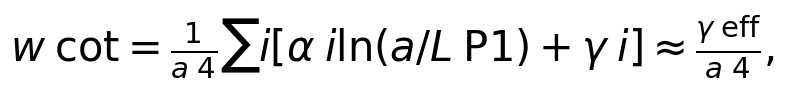

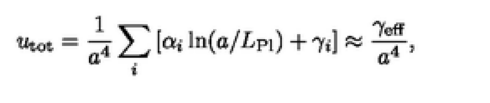

In [9]:
# Check untrained model
for i in range(10):
    generate(i, dataset)

In [10]:
print(convert_to_json(dataset[0]))  # make JSON request (message)

{'messages': [{'role': 'user', 'content': [{'type': 'text', 'text': 'Write the LaTeX representation for this image.'}, {'type': 'image', 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40 at 0x7BC5F199E630>}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}


In [11]:
# Make large JSON file for LLM model
converted_dataset = [convert_to_json(sample) for sample in dataset]

In [12]:
print(converted_dataset[1])

{'messages': [{'role': 'user', 'content': [{'type': 'text', 'text': 'Write the LaTeX representation for this image.'}, {'type': 'image', 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=120x50 at 0x7BC56D3DC560>}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'D _ { \\mu } ^ { \\alpha \\beta } \\bar { A } _ { \\mu } ^ { \\alpha \\beta } = 0 ,'}]}]}


In [13]:
trainer = SFTTrainer(  # supervised fine-tuning trainer
    model=model,
    tokenizer=tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset=converted_dataset,
    args = SFTConfig(  # configuration arguments for the trainer
        per_device_train_batch_size=2,  # 2 images per batch
        gradient_accumulation_steps=4,  # update weights after 4 batches
        warmup_steps=5,  # start to decrease learning rate after 5 steps
        max_steps=30,  # number of steps
        learning_rate=2e-4,
        fp16 = not is_bf16_supported(),  # bf16 == True, if GPU model is RTX 30+
        bf16=is_bf16_supported(),  # try Bfloat16 (Brain Floating Point) for GPU
        logging_steps=1,  # if 1, then log every step
        optim="adamw_8bit",
        weight_decay=0.01,  # penalizes the large weights
        lr_scheduler_type="linear",  # after warmup lineary decrease LR to zero
        seed=3407,
        output_dir="outputs",
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc=4,  # number of workers
        max_seq_length=2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [14]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 50,855,936 of 8,342,231,552 (0.61% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.180200
2,1.326900
3,1.403700
4,0.972700
5,0.890000
6,0.890900
7,0.702500
8,0.462500
9,0.382900
10,0.409600


TrainOutput(global_step=30, training_loss=0.3968310718735059, metrics={'train_runtime': 224.4053, 'train_samples_per_second': 1.069, 'train_steps_per_second': 0.134, 'total_flos': 1661933681209344.0, 'train_loss': 0.3968310718735059, 'epoch': 0.0034941618379291267})

\frac { N } { M } \in \mathbb { Z } , \frac { M } { P } \in \mathbb { Z } , \frac { P } { Q } \in \mathbb { Z }<|im_end|>

----------------
Generated:	\frac { N } { M } \in \mathbb { Z } , \frac { M } { P } \in \mathbb { Z } , \frac { P } { Q } \in \mathbb { Z }
Actual:		{ \frac { N } { M } } \in { \bf Z } , { \frac { M } { P } } \in { \bf Z } , { \frac { P } { Q } } \in { \bf Z }
----------------

\frac { N } { M } \in \mathbb { Z } , \frac { M } { P } \in \mathbb { Z } , \frac { P } { Q } \in \mathbb { Z }


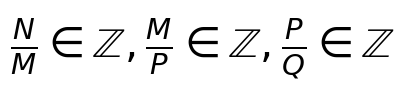

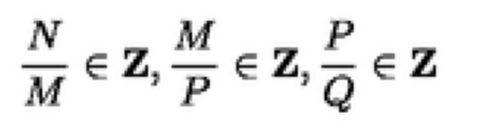

D _ { \mu } ^ { \alpha } \tilde { A } _ { \mu } ^ { \alpha } = 0 ,<|im_end|>

----------------
Generated:	D _ { \mu } ^ { \alpha } \tilde { A } _ { \mu } ^ { \alpha } = 0 ,
Actual:		D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,
----------------

D _ { \mu } ^ { \alpha } \tilde { A } _ { \mu } ^ { \alpha } = 0 ,


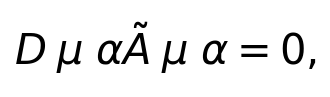

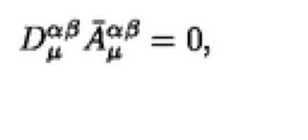

H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} \ .<|im_end|>

----------------
Generated:	H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} \ .
Actual:		H ^ { \prime } = \beta N \int d \lambda \biggl \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \biggr \} \ .
----------------

H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} \ .


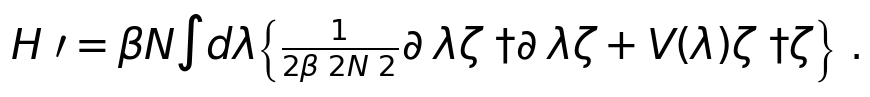

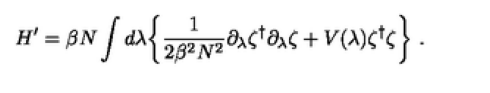

\sigma ^ { \mu } \lambda ^ { a } \frac { \lambda ^ { a } } { 2 } A ^ { \mu } .<|im_end|>

----------------
Generated:	\sigma ^ { \mu } \lambda ^ { a } \frac { \lambda ^ { a } } { 2 } A ^ { \mu } .
Actual:		\sigma ^ { \mu } \frac { \lambda ^ { a } } { 2 } A _ { \mu } ^ { a } .
----------------

\sigma ^ { \mu } \lambda ^ { a } \frac { \lambda ^ { a } } { 2 } A ^ { \mu } .


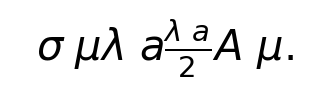

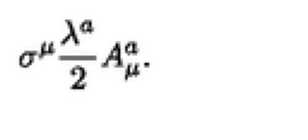

\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }<|im_end|>

----------------
Generated:	\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }
Actual:		\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }
----------------

\eta ( n _ { 1 } n _ { 2 } n k ) = \alpha ( - 1 ) ^ { n _ { 1 } + n _ { 2 } + n }


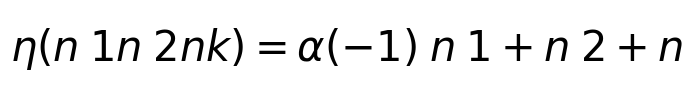

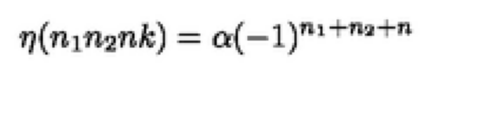

\left( 4 \pi \bar { N } \bar { \xi } ^ { 2 } ( s ) \right) ^ { - 1 } F _ { \mu } [ \xi | s ] = - \bar { D } ^ { \prime \prime } ( s ) L _ { \mu \nu } [ \xi | s ] ,<|im_end|>

----------------
Generated:	\left( 4 \pi \bar { N } \bar { \xi } ^ { 2 } ( s ) \right) ^ { - 1 } F _ { \mu } [ \xi | s ] = - \bar { D } ^ { \prime \prime } ( s ) L _ { \mu \nu } [ \xi | s ] ,
Actual:		( 4 \pi { \bar { N } } \dot { \xi } ^ { 2 } ( s ) ) ^ { - 1 } F _ { \mu } [ \xi | s ] = - { \cal D } ^ { \nu } ( s ) L _ { \mu \nu } [ \xi | s ] ,
----------------

\left( 4 \pi \bar { N } \bar { \xi } ^ { 2 } ( s ) \right) ^ { - 1 } F _ { \mu } [ \xi | s ] = - \bar { D } ^ { \prime \prime } ( s ) L _ { \mu \nu } [ \xi | s ] ,


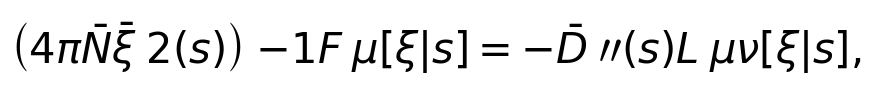

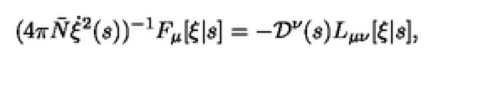

p _ { \mu } T ^ { S ^ { \mu } \rightarrow A V } = 2 m _ { T ^ { \mu } \rightarrow P V }<|im_end|>

----------------
Generated:	p _ { \mu } T ^ { S ^ { \mu } \rightarrow A V } = 2 m _ { T ^ { \mu } \rightarrow P V }
Actual:		p _ { \mu } T _ { \mu \nu } ^ { S \rightarrow A V } = 2 m i T _ { \nu } ^ { S \rightarrow P V }
----------------

p _ { \mu } T ^ { S ^ { \mu } \rightarrow A V } = 2 m _ { T ^ { \mu } \rightarrow P V }


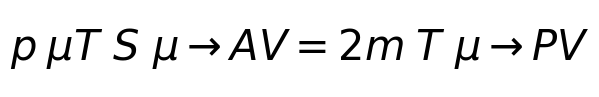

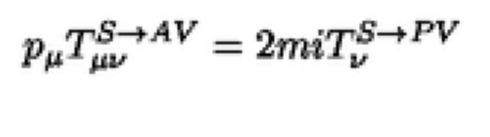

F [ r _ { - \varepsilon } ( \alpha ) ] =<|im_end|>

----------------
Generated:	F [ r _ { - \varepsilon } ( \alpha ) ] =
Actual:		F [ \tau _ { - \varepsilon } ( \alpha ) ] =
----------------

F [ r _ { - \varepsilon } ( \alpha ) ] =


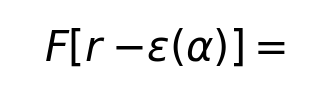

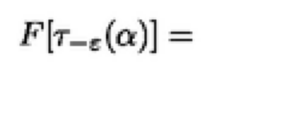

f _ { g } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \neq ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \mathrm { d e t } g _ { I J } }<|im_end|>

----------------
Generated:	f _ { g } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \neq ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \mathrm { d e t } g _ { I J } }
Actual:		f _ { 9 } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \ne ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \det g _ { I J } }
----------------

f _ { g } ^ { A } = V _ { 1 1 } \sum _ { ( n ^ { 1 } , n ^ { 2 } ) \neq ( 0 , 0 ) } \left( n ^ { I } g _ { I J } n ^ { J } \right) ^ { - 3 / 2 } \ , \quad V _ { 1 1 } = \sqrt { \mathrm { d e t } g _ { I J } }


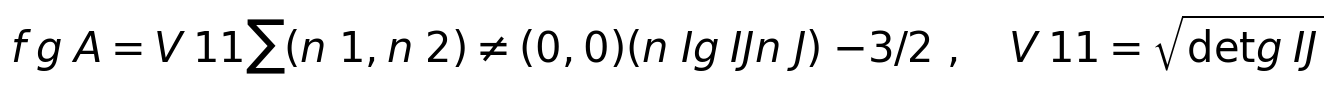

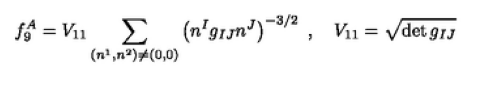

u _ { \mathrm { k o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } [ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } ] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,<|im_end|>

----------------
Generated:	u _ { \mathrm { k o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } [ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } ] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,
Actual:		u _ { \mathrm { t o t } } = { \frac { 1 } { a ^ { 4 } } } \sum _ { i } \left[ \alpha _ { i } \ln ( a / L _ { \mathrm { P l } } ) + \gamma _ { i } \right] \approx { \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } } ,
----------------

u _ { \mathrm { k o t } } = \frac { 1 } { a ^ { 4 } } \sum _ { i } [ \alpha _ { i } \ln ( a / L _ { \mathrm { P 1 } } ) + \gamma _ { i } ] \approx \frac { \gamma _ { \mathrm { e f f } } } { a ^ { 4 } } ,


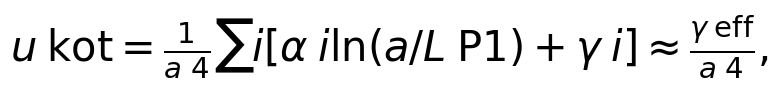

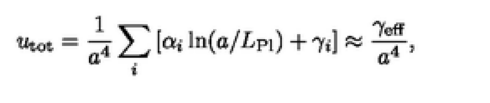

In [15]:
# Check fine-tuned model
for i in range(10):
    generate(i, dataset)